Система Лоренца:

$\dot{x} = \sigma(y-x)$

$\dot{y} = x(\rho-z)-y$

$\dot{z} = xy-\beta y$


Начальные условия:

$x(t_0) = x_0$

$y(t_0) = y_0$

$z(t_0) = z_0$

Метод Рунге-Кутты четвертого порядка (RK4): 

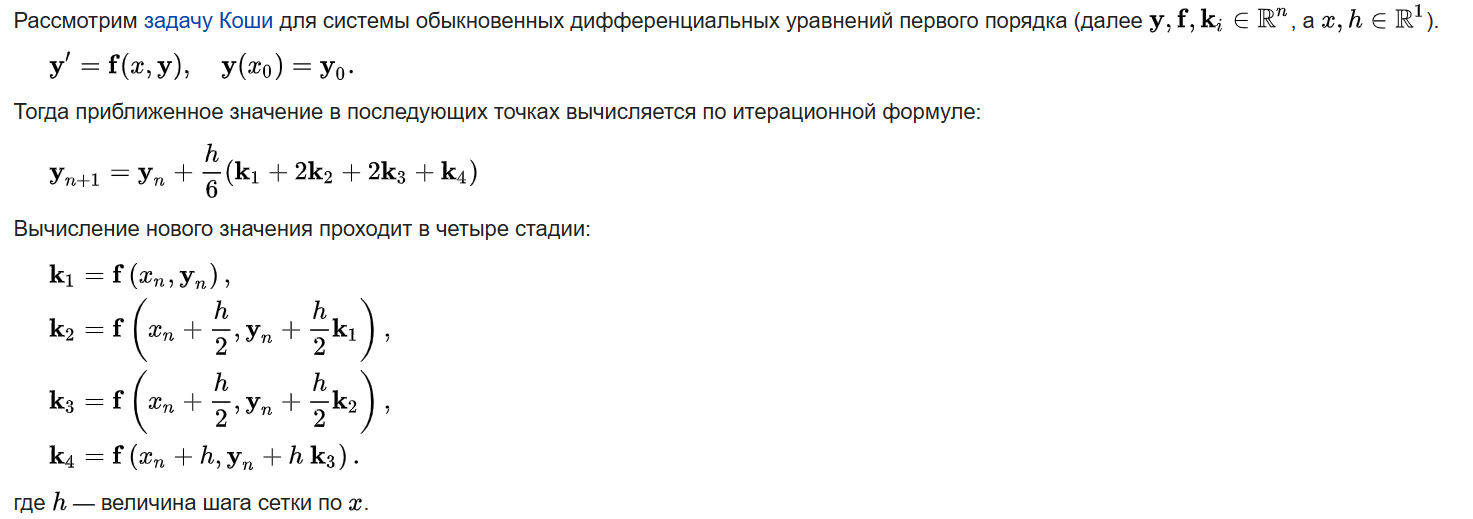

In [ ]:
#Импорт зависимостей
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.signal import find_peaks
from IPython.display import HTML

In [ ]:
#Параметры задачи
x0 = 1.0
y0 = 1.0
z0 = 1.0

sigma = 10
ro = 28
betta = 8/3

t = 0
T = 10
steps = 100
dt = T/steps

In [ ]:
#Система Лоренца
def Lorenz(state):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (ro - z) - y
    dzdt = x * y - betta * z
    return np.array([dxdt, dydt, dzdt])

In [ ]:
#Метод Рунге-Кутты4
def RK4(func, state, dt):
    k1 = func(state)
    k2 = func(state + dt * 0.5 * k1)
    k3 = func(state + dt * 0.5 * k2)
    k4 = func(state + dt * k3)
    return state + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)

In [ ]:
#Численное решение
def Solve(function, initial, t=t, T=T, dt=dt):
    t_values = np.arange(t, T + dt, dt)
    states = np.zeros((len(t_values), len(initial)))
    states[0] = initial
    for i in range(1, len(t_values)):
        states[i] = RK4(function, states[i-1], dt)
    return t_values, states

In [ ]:
#Производные системы
def Derivatives(states):
    derivatives = np.zeros_like(states)
    for i, state in enumerate(states):
        derivatives[i] = Lorenz(state)
    return derivatives

In [ ]:
#Построение фазовых диаграмм
def PhaseDiagramm(states, derivatives):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    variables = ['x', 'y', 'z']
    for i, var in enumerate(variables):
        axes[i].plot(states[:, i], derivatives[:, i], lw=0.5)
        axes[i].set_xlabel(var)
        axes[i].set_ylabel(f"{var}'")
        axes[i].set_title(f"Фазовый портрет ({var}', {var})")
        axes[i].grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
#Построение графиков координат от времени
def TimeSeries(t_values, states):
    fig, axes = plt.subplots(3, 1, figsize=(10, 8))
    variables = ['x', 'y', 'z']
    colors = ['r', 'g', 'b']
    for i, (var, color) in enumerate(zip(variables, colors)):
        axes[i].plot(t_values, states[:, i], color=color, lw=1)
        axes[i].set_ylabel(var)
        axes[i].set_xlabel('t')
        axes[i].set_title(f'{var}(t)')
        axes[i].grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
#Анализ чувствительности к начальным условиям
def Sensitivity(type_coordinate):
    newX0 = x0
    newY0 = y0
    newZ0 = z0
    label1=''
    label2=''
    name = ''
    diffName = ''
    if(type_coordinate == 1):
        newX0 = x0+0.001
        label1='x₁(t)'
        label2='x₂(t)'
        name = 'x(t)'
        diffName = '|x₁ - x₂|'
    if(type_coordinate == 2):
        newY0 = y0+0.001
        label1='y₁(t)'
        label2='y₂(t)'
        name = 'y(t)'
        diffName = '|y₁ - y₂|'
    if(type_coordinate == 3):
        newZ0 = z0+0.001
        label1='z₁(t)'
        label2='z₂(t)'
        name = 'z(t)'
        diffName = '|z₁ - z₂|'
    initial_state1 = np.array([x0, y0, z0])
    initial_state2 = np.array([newX0, newY0, newZ0])
    t_values1, states1 = Solve(Lorenz, initial_state1)
    t_values2, states2 = Solve(Lorenz, initial_state2)
    diff_x = np.abs(states1[:, 0] - states2[:, 0])
    diff_y = np.abs(states1[:, 1] - states2[:, 1])
    diff_z = np.abs(states1[:, 2] - states2[:, 2])
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    axes[0].plot(t_values1, states1[:, type_coordinate-1], 'b-', label=label1, alpha=0.7)
    axes[0].plot(t_values2, states2[:, type_coordinate-1], 'r--', label=label2, alpha=0.7)
    axes[0].set_ylabel(name)
    axes[0].set_title('Чувствительность к начальным условиям '+name+r' $\delta$ = 0.001')
    axes[0].legend()
    axes[0].grid(True)
    axes[1].semilogy(t_values1, diff_x, 'g-', label=diffName)
    axes[1].set_xlabel('Время, t')
    axes[1].set_ylabel('Разность, $\delta$')
    axes[1].set_title('Расхождение траекторий')
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
#Анимация фазовых портретов
def AnimationPhase():
    fig = plt.figure(figsize=(10, 8))
    ro_values = np.linspace(10, 40, 100)
    initial_state = np.array([x0, y0, z0])
    def update(frame):
        plt.clf()
        current_ro = ro_values[frame]
        def lorenz_temp(state):
            x, y, z = state
            return np.array([
                sigma * (y - x),
                x * (current_ro - z) - y,
                x * y - betta * z
            ])
        t_vals, states = Solve(lorenz_temp, initial_state)
        ax = fig.add_subplot(111, projection='3d')
        ax.plot(states[:, 0], states[:, 1], states[:, 2], 'b-', lw=0.5)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        ax.set_title(f'Фазовый портрет системы Лоренца, ρ = {current_ro:.2f}')
        return fig,
    anim = FuncAnimation(fig, update, frames=len(ro_values), 
                        interval=100, blit=False, repeat=True)
    #plt.close(fig)
    return HTML(anim.to_jshtml())

Бифуркационная диаграмма показывает качественные изменения в поведении динамической системы при изменении ее параметра. Для системы Лоренца она визуализирует переход от регулярного к хаотическому поведению при изменении параметра $\rho$.

Алгоритм:
- Задается диапазон значений $\rho = [\rho_L, \rho_R]$
- Для каждого $\rho_i \in [\rho_L, \rho_R]$ интегрируем систему на временном интервале $[t_0,T_{trans}]$ для вывода ее на аттрактор

$T_{trans}$ - подбираается эмпирически. Обычно $T_{trans} = 100$ хватает для системы Лоренца с параметрами $\sigma = 10$, $\beta = \frac{8}{3}$,  $\rho_i \in [0, 50]$ для выхода на аттрактор

- После выхода на аттрактор продолжаем интегрировать систему на интервале $[T_{trans}, T_{total}]$ и сохранять данные

- Для каждого набора данных, соответствующих параметру $\rho_i$, ищем локальные максимумы координаты $z$ - получим набор $\{z_i\}$

- Строим точечную диаграмму $\{\rho_i, \{z_i\}\}$

Количество точек на вертикальной прямой $\rho=\rho_i$ позволяет понять поведение системы:

- Одна точка - система в стационарном режиме

- Две точки - появление двух устойчивых орбит, система в состоянии "переключения"

- Увеличение числа точек - переход к хаосу

In [ ]:
#Бифуркационная диаграмма
def Bifurcation():
    ro_range = np.linspace(0, 50, 100)
    t_transient = 100 
    t_total = 150     
    dt = 0.01
    ro_points = []
    z_max_points = []
    initial_state = np.array([x0, y0, z0])
    for ro_val in ro_range:
        def lorenz_temp(state):
            x, y, z = state
            return np.array([
                sigma * (y - x),
                x * (ro_val - z) - y,
                x * y - betta * z
            ])
        t_vals, states = Solve(lorenz_temp, initial_state, 0, t_transient, dt)
        new_initial = states[-1]
        t_vals, states = Solve(lorenz_temp, new_initial, 0, t_total - t_transient, dt)
        z_values = states[:, 2]
        peaks, _ = find_peaks(z_values, height=0, distance=10)
        for peak in peaks:
            ro_points.append(ro_val)
            z_max_points.append(z_values[peak])
    plt.figure(figsize=(12, 6))
    plt.plot(ro_points, z_max_points, 'b.', markersize=0.5, alpha=0.7)
    plt.xlabel('Параметр ρ')
    plt.ylabel('Локальные максимумы z')
    plt.title('Бифуркационная диаграмма системы Лоренца')
    plt.grid(True, alpha=0.3)
    plt.show()

Сечения Пуанкаре - это пересечения траектории в фазовом пространстве с секущей поверхностью, которая должна быть:

- Трансверсальной: пересекает траектории под ненулевым углом

- Не инвариантной: траектории действительно пересекают её, а не скользят по ней

In [ ]:
#Сечения Пуанкаре
def Poincare(ro_value=28, plane='z', value=25, direction='positive'):
    initial_state = np.array([x0, y0, z0])
    t_start, t_end, dt = 0, 100, 0.01
    def lorenz_temp(state):
        x, y, z = state
        return np.array([
            sigma * (y - x),
            x * (ro_value - z) - y,
            x * y - betta * z
        ])
    t_vals, states = Solve(lorenz_temp, initial_state, t_start, t_end, dt)
    intersections = []    
    for i in range(1, len(states)):
        prev_state = states[i-1]
        curr_state = states[i]
        if plane == 'z':
            if (prev_state[2] - value) * (curr_state[2] - value) <= 0:
                t_intersect = (value - prev_state[2]) / (curr_state[2] - prev_state[2])
                x_intersect = prev_state[0] + t_intersect * (curr_state[0] - prev_state[0])
                y_intersect = prev_state[1] + t_intersect * (curr_state[1] - prev_state[1])
                if direction == 'positive' and curr_state[2] > prev_state[2]:
                    intersections.append([x_intersect, y_intersect])
                elif direction == 'negative' and curr_state[2] < prev_state[2]:
                    intersections.append([x_intersect, y_intersect])
                elif direction == 'both':
                    intersections.append([x_intersect, y_intersect])
    intersections = np.array(intersections)
    return intersections

In [ ]:
#Анализ сечений Пуанкаре
def PoincareAnalysis(ro_values):    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))  
    axes = axes.flatten()    
    for idx, ro in enumerate(ro_values):
        intersections = Poincare(ro)
        if len(intersections) == 0:
            continue
        n_points = len(intersections)
        x_points = intersections[:, 0]
        if n_points < 10:
            regime = "Периодический"
            color = 'green'
        elif n_points < 30:
            regime = "Переходный" 
            color = 'orange'
        else:
            regime = "Хаотический"
            color = 'red'
        axes[idx].plot(intersections[:, 0], intersections[:, 1], 'b.', markersize=3)
        axes[idx].set_xlabel('x')
        axes[idx].set_ylabel('y')
        axes[idx].set_title(r'$\rho$ = '+f'{ro}')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].text(0.05, 0.95, f'{regime}\nТочек: {n_points}', 
                       transform=axes[idx].transAxes,
                       bbox=dict(boxstyle="round", facecolor=color, alpha=0.7),
                       verticalalignment='top')
    fig.suptitle('Сечения Пуанкаре, z=25')
    plt.tight_layout()
    plt.show()

In [ ]:
#Анализ сечений Пуанкаре
def PoincareAnalysis(ro_values):    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))  
    axes = axes.flatten()    
    for idx, ro in enumerate(ro_values):
        intersections = Poincare(ro)
        if len(intersections) == 0:
            continue
        n_points = len(intersections)
        x_points = intersections[:, 0]
        if n_points < 10:
            regime = "Периодический"
            color = 'green'
        elif n_points < 30:
            regime = "Переходный" 
            color = 'orange'
        else:
            regime = "Хаотический"
            color = 'red'
        axes[idx].plot(intersections[:, 0], intersections[:, 1], 'b.', markersize=3)
        axes[idx].set_xlabel('x')
        axes[idx].set_ylabel('y')
        axes[idx].set_title(r'$\rho$ = '+f'{ro}')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].text(0.05, 0.95, f'{regime}\nТочек: {n_points}', 
                       transform=axes[idx].transAxes,
                       bbox=dict(boxstyle="round", facecolor=color, alpha=0.7),
                       verticalalignment='top')
    fig.suptitle('Сечения Пуанкаре, z=25')
    plt.tight_layout()
    plt.show()

In [ ]:
#Анализ изменения режима
def RegimeTransition():
    ro_range = np.linspace(10, 40, 20)
    point_counts = []
    for ro in ro_range:
        intersections = Poincare(ro)
        point_counts.append(len(intersections))
    plt.figure(figsize=(10, 6))
    plt.plot(ro_range, point_counts, 'bo-', linewidth=2, markersize=6)
    plt.xlabel(r'$\rho$')
    plt.ylabel('Количество точек в сечении')
    plt.title('Переход к хаосу')
    plt.grid(True, alpha=0.3)
    plt.axvline(x=24, color='red', linestyle='--', alpha=0.7, label='Начало хаоса')
    plt.axvline(x=13, color='orange', linestyle='--', alpha=0.7, label='Бифуркация')
    plt.legend()
    plt.show()

In [ ]:
initial_state = np.array([x0, y0, z0])
t_values, states = Solve(Lorenz, initial_state)
derivatives = Derivatives(states)
PhaseDiagramm(states, derivatives)

In [ ]:
TimeSeries(t_values, states)

In [ ]:
Sensitivity(1)

In [ ]:
Sensitivity(2)

In [ ]:
Sensitivity(3)

In [ ]:
AnimationPhase()

In [ ]:
Bifurcation()

In [ ]:
PoincareAnalysis(ro_values=[19, 23, 29, 41])

In [ ]:
RegimeTransition()